# Resource Gathering — Multi-Objective Reinforcement Learning

**Curso:** Aprendizaje por Refuerzo — Maestría en Ingeniería
**Autores:** Juan Diego Sánchez
**Fecha:** 2026-05-22

Este notebook explora el ambiente *Resource Gathering* de MO-Gymnasium usando algoritmos de **MORL (Multi-Objective Reinforcement Learning)**. Implementamos dos enfoques: **Q-Learning con Escalarización Lineal** y **MPMOQLearning con GPI-LS**, y comparamos sus capacidades para aproximar el frente de Pareto tridimensional.

In [1]:
!pip install mo-gymnasium morl-baselines imageio --quiet

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from mpl_toolkits.mplot3d import Axes3D
import mo_gymnasium as mo_gym
from mo_gymnasium.wrappers import MORecordEpisodeStatistics
from morl_baselines.multi_policy.multi_policy_moqlearning.mp_mo_q_learning import MPMOQLearning
from collections import defaultdict
import os, warnings
warnings.filterwarnings('ignore')

from IPython.display import display, HTML
import imageio

os.makedirs('videos', exist_ok=True)
os.makedirs('resources/env_gifs', exist_ok=True)
os.makedirs('resources/agent_gifs', exist_ok=True)
os.makedirs('resources/agent_videos', exist_ok=True)

ENV_ID  = 'resource-gathering-v0'
GAMMA   = 0.95
np.random.seed(42)
print('Dependencias cargadas correctamente')

/opt/miniconda3/envs/cardozoenv/lib/python3.10/site-packages/pygame/pkgdata.py:25: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_stream, resource_exists


Dependencias cargadas correctamente


## 2. Introducción a MORL con 3 Objetivos

En MORL, el agente recibe un **vector de recompensas** $\mathbf{r} \in \mathbb{R}^k$ en cada paso. Para $k=3$:

$$\mathbf{r} = (r_1, r_2, r_3) \in \mathbb{R}^3$$

Una política $\pi$ **domina** a $\pi'$ si es al menos tan buena en todos los objetivos y estrictamente mejor en al menos uno:

$$\pi \succ \pi' \iff \forall i:\, V_i(\pi) \geq V_i(\pi') \;\land\; \exists j:\, V_j(\pi) > V_j(\pi')$$

El **Frente de Pareto** es el conjunto de políticas no dominadas. Con 3 objetivos el frente es una **superficie** en $\mathbb{R}^3$. Para visualizarlo usamos proyecciones 2D.

**Paradigmas:**
- **Escalarización**: $r_{scalar} = \mathbf{w} \cdot \mathbf{r}$ — una política por vector de pesos; solo descubre el casco convexo del frente.
- **Multi-política** (GPI-LS): aprende múltiples políticas y descubre el frente completo en una sola ejecución.

## 3. El Ambiente: Resource Gathering

Resource Gathering es un ambiente de cuadrícula **5×5** con **3 objetivos en conflicto**.

### Mapa

```
Col:  0    1    2    3    4
Row 0: .    .    R1   E2   .
Row 1: .    .    E1   .    R2
Row 2: .    .    .    .    .
Row 3: .    .    .    .    .
Row 4: .    .    H    .    .
```

- **H**: Casa (inicio y meta, fila 4 col 2)
- **R1**: Oro (fila 0 col 2)
- **R2**: Diamante (fila 1 col 4)
- **E1, E2**: Enemigos (10 % de probabilidad de muerte al pisarlos)

### Especificación

| Componente | Descripción |
|---|---|
| **Estado** | $[x, y, \text{tiene\_oro}, \text{tiene\_diamante}]$ — 4 enteros |
| **Acciones** | 4 — arriba(0), abajo(1), izquierda(2), derecha(3) |
| **Recompensa** | $\mathbf{r} = [r_{muerte}, r_{oro}, r_{diamante}]$ |

### Vector de Recompensa

$$\mathbf{r} = \begin{cases} r_{muerte} = -1 & \text{si el agente muere} \\ r_{oro} = +1 & \text{si retorna a casa con oro} \\ r_{diamante} = +1 & \text{si retorna a casa con diamante} \end{cases}$$

Fuera de estos eventos, todos los componentes son $0$ (sin penalización por tiempo).

### Conflicto entre Objetivos

Para recoger **ambos recursos**, el agente debe pasar cerca de los dos enemigos **dos veces** (ida y vuelta), aumentando el riesgo acumulado de muerte. Las 4 estrategias Pareto-óptimas son:

1. **Nada** — ir a casa de inmediato: $(0, 0, 0)$
2. **Solo oro** — recoger R1 y regresar: baja penalización de muerte, obtiene oro
3. **Solo diamante** — recoger R2 y regresar: riesgo similar, obtiene diamante
4. **Ambos** — mayor riesgo acumulado, obtiene oro **y** diamante

In [3]:
env = mo_gym.make(ENV_ID, render_mode='rgb_array')
print('=' * 55)
print('   RESOURCE GATHERING — INFORMACIÓN DEL AMBIENTE')
print('=' * 55)
print(f'  Espacio de estados  : {env.observation_space}')
print(f'  Espacio de acciones : {env.action_space}')
print(f'  Espacio de recomp.  : {env.unwrapped.reward_space}')

print('\n--- Ejemplo de interacción (política aleatoria) ---')
obs, _ = env.reset()
print(f'  Estado inicial: {obs}  (x={obs[0]}, y={obs[1]}, oro={obs[2]}, diamante={obs[3]})')
action_names = ['Arriba', 'Abajo', 'Izquierda', 'Derecha']
for step in range(10):
    action = env.action_space.sample()
    next_obs, r_vec, terminated, truncated, _ = env.step(action)
    print(f'  Paso {step+1:2d}: {action_names[action]:>9} | obs={next_obs} | r={r_vec}')
    obs = next_obs
    if terminated or truncated:
        print('           -> Episodio terminado')
        break
env.close()

   RESOURCE GATHERING — INFORMACIÓN DEL AMBIENTE
  Espacio de estados  : Box(0, 5, (4,), int32)
  Espacio de acciones : Discrete(4)
  Espacio de recomp.  : Box([-1.  0.  0.], [0. 1. 1.], (3,), float32)

--- Ejemplo de interacción (política aleatoria) ---
  Estado inicial: [4 2 0 0]  (x=4, y=2, oro=0, diamante=0)
  Paso  1:   Derecha | obs=[4 3 0 0] | r=[0. 0. 0.]
  Paso  2:   Derecha | obs=[4 4 0 0] | r=[0. 0. 0.]
  Paso  3:     Abajo | obs=[4 4 0 0] | r=[0. 0. 0.]
  Paso  4:   Derecha | obs=[4 4 0 0] | r=[0. 0. 0.]
  Paso  5: Izquierda | obs=[4 3 0 0] | r=[0. 0. 0.]
  Paso  6:     Abajo | obs=[4 3 0 0] | r=[0. 0. 0.]
  Paso  7:    Arriba | obs=[3 3 0 0] | r=[0. 0. 0.]
  Paso  8:     Abajo | obs=[4 3 0 0] | r=[0. 0. 0.]
  Paso  9: Izquierda | obs=[4 2 0 0] | r=[0. 0. 0.]
           -> Episodio terminado


## 4. Visualización del Ambiente

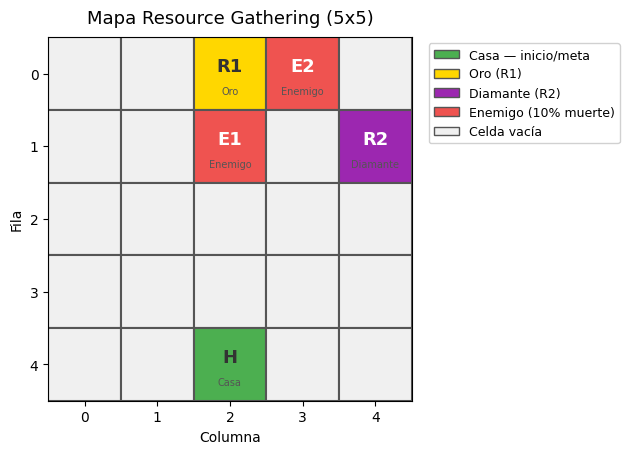

In [4]:
def plot_rg_map(ax=None, title='Mapa Resource Gathering (5x5)'):
    """Visualiza el mapa 5x5 de Resource Gathering con matplotlib."""
    if ax is None:
        fig, ax = plt.subplots(figsize=(5.5, 5.5))

    MAP = [
        [' ', ' ', 'R1', 'E2', ' '],
        [' ', ' ', 'E1', ' ',  'R2'],
        [' ', ' ', ' ',  ' ',  ' '],
        [' ', ' ', ' ',  ' ',  ' '],
        [' ', ' ', 'H',  ' ',  ' '],
    ]
    cell_colors = {
        ' ':  '#F0F0F0',
        'H':  '#4CAF50',
        'R1': '#FFD700',
        'R2': '#9C27B0',
        'E1': '#EF5350',
        'E2': '#EF5350',
    }
    cell_text = {'H': 'Casa', 'R1': 'Oro', 'R2': 'Diamante',
                 'E1': 'Enemigo', 'E2': 'Enemigo'}

    for row in range(5):
        for col in range(5):
            cell = MAP[row][col]
            color = cell_colors[cell]
            rect = plt.Rectangle([col, 4 - row], 1, 1,
                                  facecolor=color, edgecolor='#555', linewidth=1.5)
            ax.add_patch(rect)
            label = cell_text.get(cell, '')
            if label:
                ax.text(col + 0.5, 4 - row + 0.6, cell,
                        ha='center', va='center', fontsize=13, fontweight='bold',
                        color='white' if cell in ('E1','E2','R2') else '#333')
                ax.text(col + 0.5, 4 - row + 0.25, label,
                        ha='center', va='center', fontsize=7, color='#555')

    ax.set_xlim(0, 5); ax.set_ylim(0, 5)
    ax.set_aspect('equal')
    ax.set_title(title, fontsize=13, pad=10)
    ax.set_xticks(np.arange(0.5, 5.5)); ax.set_xticklabels(range(5))
    ax.set_yticks(np.arange(0.5, 5.5)); ax.set_yticklabels(range(4, -1, -1))
    ax.set_xlabel('Columna'); ax.set_ylabel('Fila')

    legend_elements = [
        mpatches.Patch(facecolor='#4CAF50', edgecolor='#555', label='Casa — inicio/meta'),
        mpatches.Patch(facecolor='#FFD700', edgecolor='#555', label='Oro (R1)'),
        mpatches.Patch(facecolor='#9C27B0', edgecolor='#555', label='Diamante (R2)'),
        mpatches.Patch(facecolor='#EF5350', edgecolor='#555', label='Enemigo (10% muerte)'),
        mpatches.Patch(facecolor='#F0F0F0', edgecolor='#555', label='Celda vacía'),
    ]
    ax.legend(handles=legend_elements, loc='upper left',
              bbox_to_anchor=(1.03, 1.0), fontsize=9, framealpha=0.9)
    return ax


fig, ax = plt.subplots(figsize=(6, 5.5))
plot_rg_map(ax)
plt.tight_layout()
plt.savefig('videos/rg_map.png', dpi=100, bbox_inches='tight')
plt.show()

In [5]:
def record_episode(env_id, policy_fn, filepath, fps=5, max_steps=300):
    """Graba un episodio y lo guarda como MP4. Retorna los frames."""
    env = mo_gym.make(env_id, render_mode='rgb_array')
    obs, _ = env.reset()
    frames, terminated, truncated, step = [], False, False, 0
    while not (terminated or truncated) and step < max_steps:
        frame = env.render()
        if frame is not None:
            frames.append(frame)
        action = policy_fn(obs)
        obs, r_vec, terminated, truncated, _ = env.step(action)
        step += 1
    frame = env.render()
    if frame is not None:
        frames.append(frame)
    env.close()
    if not frames:
        print('  Advertencia: sin frames.')
        return []
    mp4_path = filepath + '.mp4'
    writer = imageio.get_writer(mp4_path, fps=fps)
    for f in frames:
        writer.append_data(f)
    writer.close()
    print(f'  Video guardado: {mp4_path}  ({step} pasos, {len(frames)} frames)')
    return frames

def show_video(filepath, width=380):
    mp4 = filepath + '.mp4'
    display(HTML(
        f'<video width="{width}" controls loop autoplay muted>'
        f'<source src="{mp4}" type="video/mp4"></video>'
    ))

In [6]:
print('Grabando episodio con politica aleatoria...')
random_policy = lambda obs: int(np.random.randint(4))
frames_random = record_episode(ENV_ID, random_policy, 'videos/rg_random', fps=5)

if frames_random:
    imageio.mimsave('resources/env_gifs/rg_random.gif', frames_random, fps=5, loop=0)
    print('GIF guardado: resources/env_gifs/rg_random.gif')
    show_video('videos/rg_random')

Grabando episodio con politica aleatoria...


  Video guardado: videos/rg_random.mp4  (2 pasos, 3 frames)
GIF guardado: resources/env_gifs/rg_random.gif


## 5. Frente de Pareto Verdadero

Resource Gathering tiene un frente de Pareto **conocido analíticamente**: 4 políticas no dominadas correspondientes a las 4 estrategias descritas. Podemos obtenerlo directamente del ambiente con `env.unwrapped.pareto_front(gamma)`.

Cada punto es un vector $\mathbf{V}^\pi = [V_{muerte}^\pi, V_{oro}^\pi, V_{diamante}^\pi]$ que representa el **retorno descontado esperado** de la política $\pi$ en cada objetivo.

In [7]:
env_pf = mo_gym.make(ENV_ID)
TRUE_PARETO = env_pf.unwrapped.pareto_front(gamma=GAMMA)
env_pf.close()

print(f'Frente de Pareto verdadero (gamma={GAMMA}):')
print(f'  {len(TRUE_PARETO)} politicas no dominadas\n')
print(f'  {"Politica":<12} {"r_muerte":>10} {"r_oro":>10} {"r_diamante":>12}')
print('  ' + '-' * 50)
strategy_names = ['Nada', 'Solo oro', 'Solo diamante', 'Ambos recursos']
for i, pt in enumerate(TRUE_PARETO):
    name = strategy_names[i] if i < len(strategy_names) else f'P{i+1}'
    print(f'  {name:<12} {pt[0]:>10.4f} {pt[1]:>10.4f} {pt[2]:>12.4f}')

Frente de Pareto verdadero (gamma=0.95):
  3 politicas no dominadas

  Politica       r_muerte      r_oro   r_diamante
  --------------------------------------------------
  Nada             0.0000     0.0000       0.5987
  Solo oro         0.0000     0.5404       0.0000
  Solo diamante    -0.0698     0.4389       0.4389


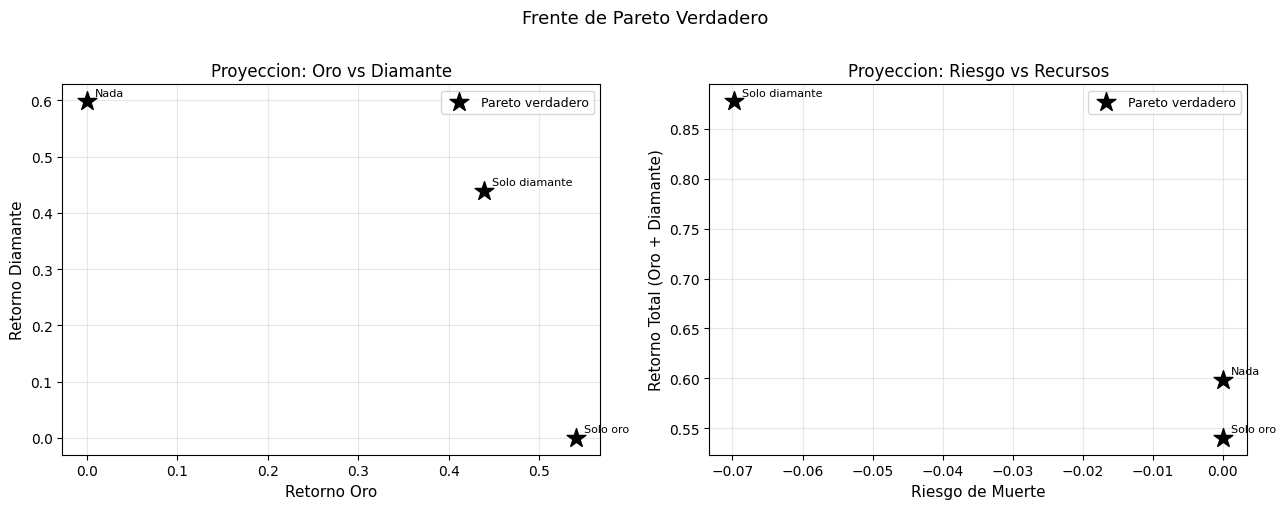

In [8]:
def plot_pareto_rg(true_pts, discovered_list=None, labels=None,
                   title='Frente de Pareto — Resource Gathering'):
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    colors_disc = ['#2196F3', '#FF9800', '#9C27B0', '#4CAF50', '#F44336']
    true_arr = np.array(true_pts)

    for ax_idx, (xi, yi, xlabel, ylabel, proj_title) in enumerate([
        (1, 2, 'Retorno Oro', 'Retorno Diamante', 'Proyeccion: Oro vs Diamante'),
        (0, None, 'Riesgo de Muerte', 'Retorno Total (Oro + Diamante)',
         'Proyeccion: Riesgo vs Recursos'),
    ]):
        ax = axes[ax_idx]
        if yi is None:
            ty = true_arr[:, 1] + true_arr[:, 2]
        else:
            ty = true_arr[:, yi]
        tx = true_arr[:, xi]

        ax.scatter(tx, ty, c='black', s=200, zorder=6, marker='*',
                   label='Pareto verdadero')
        for i, pt in enumerate(true_pts):
            names = ['Nada', 'Solo oro', 'Solo diamante', 'Ambos']
            name = names[i] if i < len(names) else f'P{i}'
            ax.annotate(name, (tx[i], ty[i]),
                        textcoords='offset points', xytext=(6, 4), fontsize=8)

        if discovered_list and labels:
            for j, (pts, lbl) in enumerate(zip(discovered_list, labels)):
                pts_arr = np.array(pts)
                dy = (pts_arr[:, 1] + pts_arr[:, 2]) if yi is None else pts_arr[:, yi]
                dx = pts_arr[:, xi]
                ax.scatter(dx, dy, c=colors_disc[j % len(colors_disc)],
                           s=90, alpha=0.75, zorder=5, label=lbl)

        ax.set_xlabel(xlabel, fontsize=11)
        ax.set_ylabel(ylabel, fontsize=11)
        ax.set_title(proj_title, fontsize=12)
        ax.legend(fontsize=9)
        ax.grid(alpha=0.3)

    plt.suptitle(title, fontsize=13, y=1.01)
    plt.tight_layout()
    return fig

fig = plot_pareto_rg(TRUE_PARETO, title='Frente de Pareto Verdadero')
plt.savefig('videos/rg_pareto_true.png', dpi=100, bbox_inches='tight')
plt.show()

## 6. Enfoque 1: Q-Learning con Escalarización Lineal

### Escalarización Lineal

Con un vector de pesos $\mathbf{w} = [w_{muerte}, w_{oro}, w_{diamante}]$, convertimos el vector de recompensas en un escalar:

$$r_{scalar} = \mathbf{w} \cdot \mathbf{r} = w_{muerte}\,r_{muerte} + w_{oro}\,r_{oro} + w_{diamante}\,r_{diamante}$$

Cada $\mathbf{w}$ produce una política diferente, explorable en el frente de Pareto.

### Actualización Q-Learning

$$Q(s,a) \leftarrow Q(s,a) + \alpha \left[ \mathbf{w}\cdot\mathbf{r} + \gamma \max_{a'} Q(s',a') - Q(s,a) \right]$$

### Limitación

La escalarización lineal solo puede descubrir el **casco convexo** del frente de Pareto. Las políticas que corresponden a partes no convexas del frente son inaccesibles con ningún $\mathbf{w}$.

In [9]:
class ScalarizedQLearning:
    """Q-Learning tabular con escalarización lineal para MORL.
    Resource-Gathering: r_vec = [r_death, r_gold, r_diamond]
    Pesos: w = [w_death, w_gold, w_diamond]
    """

    def __init__(self, n_actions, weight, alpha=0.3, gamma=0.95,
                 epsilon=1.0, epsilon_min=0.05, epsilon_decay=0.998):
        self.n_actions   = n_actions
        self.w           = np.array(weight, dtype=float)
        self.alpha       = alpha
        self.gamma       = gamma
        self.epsilon     = epsilon
        self.epsilon_min = epsilon_min
        self.eps_decay   = epsilon_decay
        self.Q           = defaultdict(lambda: np.zeros(n_actions))

    def _key(self, obs):
        return tuple(np.asarray(obs, dtype=int))

    def select_action(self, obs, greedy=False):
        if not greedy and np.random.random() < self.epsilon:
            return np.random.randint(self.n_actions)
        return int(np.argmax(self.Q[self._key(obs)]))

    def update(self, obs, action, r_vec, next_obs, done):
        s, s2 = self._key(obs), self._key(next_obs)
        r = float(np.dot(self.w, r_vec))
        td_target = r if done else r + self.gamma * np.max(self.Q[s2])
        self.Q[s][action] += self.alpha * (td_target - self.Q[s][action])
        self.epsilon = max(self.epsilon_min, self.epsilon * self.eps_decay)

    def train(self, env_id, n_episodes=2000, max_steps=200):
        """Retorna (hist_death, hist_gold, hist_diamond) por episodio."""
        hd, hg, hdm = [], [], []
        for _ in range(n_episodes):
            env = mo_gym.make(env_id)
            obs, _ = env.reset()
            ep_d = ep_g = ep_dm = 0.0
            for _ in range(max_steps):
                a = self.select_action(obs)
                n_obs, r_vec, term, trunc, _ = env.step(a)
                self.update(obs, a, r_vec, n_obs, term or trunc)
                ep_d  += r_vec[0]   # -1 si muerto
                ep_g  += r_vec[1]   # +1 si retorno con oro
                ep_dm += r_vec[2]   # +1 si retorno con diamante
                obs = n_obs
                if term or trunc:
                    break
            env.close()
            hd.append(ep_d); hg.append(ep_g); hdm.append(ep_dm)
        return np.array(hd), np.array(hg), np.array(hdm)

    def evaluate(self, env_id, n_eval=20):
        """Retorna (mean_death, mean_gold, mean_diamond) para el frente de Pareto."""
        deaths, golds, diamonds = [], [], []
        for _ in range(n_eval):
            env = mo_gym.make(env_id)
            obs, _ = env.reset()
            ep_d = ep_g = ep_dm = 0.0
            gamma_t = 1.0
            for _ in range(200):
                a = self.select_action(obs, greedy=True)
                obs, r_vec, term, trunc, _ = env.step(a)
                ep_d  += gamma_t * r_vec[0]
                ep_g  += gamma_t * r_vec[1]
                ep_dm += gamma_t * r_vec[2]
                gamma_t *= self.gamma
                if term or trunc:
                    break
            env.close()
            deaths.append(ep_d); golds.append(ep_g); diamonds.append(ep_dm)
        return float(np.mean(deaths)), float(np.mean(golds)), float(np.mean(diamonds))

In [10]:
N_EPS = 2000
WEIGHT_CONFIGS = [
    ([0.0,  1.0, 0.0], 'Solo oro'),
    ([0.0,  0.0, 1.0], 'Solo diamante'),
    ([0.0,  0.5, 0.5], 'Balance recursos'),
    ([-0.5, 0.5, 0.5], 'Evitar muerte + balance'),
    ([0.0,  0.2, 0.8], 'Priorizar diamante'),
]

agents_scalar = {}
hist_all = {}
for weight, label in WEIGHT_CONFIGS:
    print(f'Entrenando  w={weight}  ({label})...')
    ag = ScalarizedQLearning(n_actions=4, weight=weight, gamma=GAMMA)
    hd, hg, hdm = ag.train(ENV_ID, n_episodes=N_EPS)
    agents_scalar[label] = ag
    hist_all[label] = (hd, hg, hdm)
    print(f'  Completado.')

Entrenando  w=[0.0, 1.0, 0.0]  (Solo oro)...


  Completado.
Entrenando  w=[0.0, 0.0, 1.0]  (Solo diamante)...


  Completado.
Entrenando  w=[0.0, 0.5, 0.5]  (Balance recursos)...


  Completado.
Entrenando  w=[-0.5, 0.5, 0.5]  (Evitar muerte + balance)...


  Completado.
Entrenando  w=[0.0, 0.2, 0.8]  (Priorizar diamante)...


  Completado.


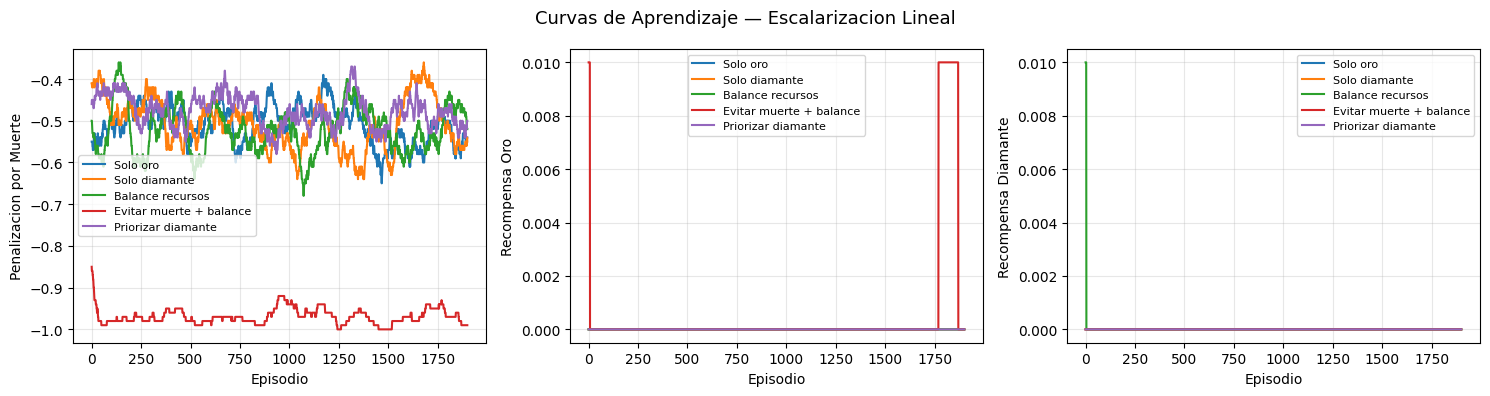

In [11]:
W = 100   # ventana de suavizado

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
titles_idx = [('Penalizacion por Muerte', 0),
              ('Recompensa Oro', 1),
              ('Recompensa Diamante', 2)]

for ax, (title, k) in zip(axes, titles_idx):
    for label, (hd, hg, hdm) in hist_all.items():
        data = [hd, hg, hdm][k]
        smooth = np.convolve(data, np.ones(W)/W, 'valid')
        ax.plot(smooth, label=label, linewidth=1.5)
    ax.set_xlabel('Episodio')
    ax.set_ylabel(title)
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

plt.suptitle('Curvas de Aprendizaje — Escalarizacion Lineal', fontsize=13)
plt.tight_layout()
plt.savefig('videos/rg_learning_curves.png', dpi=100, bbox_inches='tight')
plt.show()

Evaluando politicas (n_eval=20 por configuracion):
  Configuracion                    muerte      oro   diamante
  ------------------------------------------------------------
  Solo oro                          0.000    0.000      0.000
  Solo diamante                    -0.135    0.000      0.000
  Balance recursos                 -0.090    0.000      0.000
  Evitar muerte + balance          -0.354    0.000      0.000
  Priorizar diamante                0.000    0.000      0.000


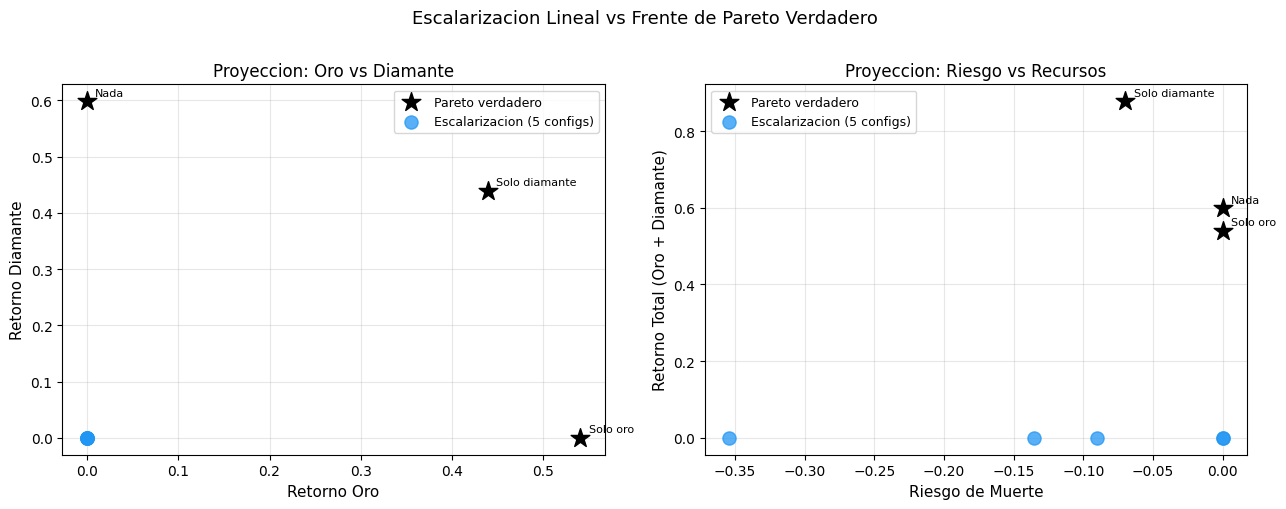

In [12]:
scalar_pts = []
print(f'Evaluando politicas (n_eval=20 por configuracion):')
print(f'  {"Configuracion":<30} {"muerte":>8} {"oro":>8} {"diamante":>10}')
print('  ' + '-'*60)
for weight, label in WEIGHT_CONFIGS:
    ag = agents_scalar[label]
    d, g, dm = ag.evaluate(ENV_ID, n_eval=20)
    scalar_pts.append([d, g, dm])
    print(f'  {label:<30} {d:>8.3f} {g:>8.3f} {dm:>10.3f}')

scalar_pts = np.array(scalar_pts)

fig = plot_pareto_rg(
    TRUE_PARETO,
    discovered_list=[scalar_pts.tolist()],
    labels=[f'Escalarizacion ({len(scalar_pts)} configs)'],
    title='Escalarizacion Lineal vs Frente de Pareto Verdadero'
)
plt.savefig('videos/rg_pareto_scalar.png', dpi=100, bbox_inches='tight')
plt.show()

In [13]:
# Video del mejor agente (balance recursos)
best_label = 'Balance recursos'
best_agent = agents_scalar[best_label]
policy_fn  = lambda obs: best_agent.select_action(obs, greedy=True)

print(f'Grabando video del agente escalarizado ({best_label})...')
frames_scalar = record_episode(ENV_ID, policy_fn, 'videos/rg_scalar_best', fps=4)
if frames_scalar:
    imageio.mimsave('resources/agent_gifs/rg_scalar.gif', frames_scalar, fps=4, loop=0)
    print('GIF guardado: resources/agent_gifs/rg_scalar.gif')
    show_video('videos/rg_scalar_best')

Grabando video del agente escalarizado (Balance recursos)...


  Video guardado: videos/rg_scalar_best.mp4  (100 pasos, 101 frames)


GIF guardado: resources/agent_gifs/rg_scalar.gif


## 7. Análisis de Parámetros — Escalarización

### Impacto de $\gamma$ (factor de descuento)

Un $\gamma$ bajo hace al agente **miope**: prefiere recompensas inmediatas y evita los recursos lejanos (menos pasos al enemigo → menor riesgo acumulado). Con $\gamma = 1.0$ el agente valora igualmente recompensas futuras y presentes.

  gamma=0.85: muerte=-0.096  oro=0.000  diamante=0.000


  gamma=0.90: muerte=-0.108  oro=0.000  diamante=0.000


  gamma=0.95: muerte=-0.180  oro=0.000  diamante=0.000


  gamma=1.00: muerte=-0.067  oro=0.000  diamante=0.000


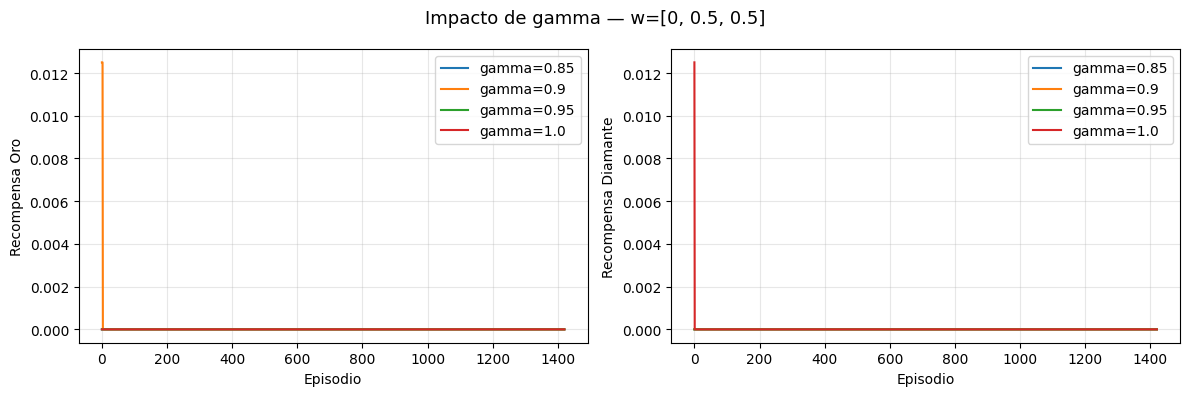


Insight: gamma bajo -> agente miope -> evita recursos lejanos (menor riesgo)
          gamma alto -> valora recompensas futuras -> colecta mas recursos


In [14]:
GAMMAS = [0.85, 0.90, 0.95, 1.0]
W_TEST  = [0.0, 0.5, 0.5]   # balance recursos

gamma_results = {}
for g in GAMMAS:
    ag = ScalarizedQLearning(n_actions=4, weight=W_TEST, gamma=g, epsilon_decay=0.998)
    hd, hg, hdm = ag.train(ENV_ID, n_episodes=1500)
    d, gold, diam = ag.evaluate(ENV_ID, n_eval=15)
    gamma_results[g] = {'death': d, 'gold': gold, 'diamond': diam,
                        'hist_gold': hg, 'hist_diamond': hdm}
    print(f'  gamma={g:.2f}: muerte={d:.3f}  oro={gold:.3f}  diamante={diam:.3f}')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for g, res in gamma_results.items():
    smooth_g  = np.convolve(res['hist_gold'],    np.ones(80)/80, 'valid')
    smooth_dm = np.convolve(res['hist_diamond'],  np.ones(80)/80, 'valid')
    axes[0].plot(smooth_g,  label=f'gamma={g}', linewidth=1.5)
    axes[1].plot(smooth_dm, label=f'gamma={g}', linewidth=1.5)

for ax, title in zip(axes, ['Recompensa Oro', 'Recompensa Diamante']):
    ax.set_xlabel('Episodio'); ax.set_ylabel(title)
    ax.legend(); ax.grid(alpha=0.3)

plt.suptitle('Impacto de gamma — w=[0, 0.5, 0.5]', fontsize=13)
plt.tight_layout()
plt.savefig('videos/rg_gamma_analysis.png', dpi=100, bbox_inches='tight')
plt.show()

print('\nInsight: gamma bajo -> agente miope -> evita recursos lejanos (menor riesgo)')
print('          gamma alto -> valora recompensas futuras -> colecta mas recursos')

### Impacto de $\epsilon$-decay (exploración)

Un decay muy rápido (epsilon cae a 0.05 en pocos episodios) puede llevar a convergencia prematura en una política subóptima. Un decay lento mantiene exploración pero tarda más en converger.

  eps_decay=0.9900: oro=0.000  diamante=0.000


  eps_decay=0.9950: oro=0.000  diamante=0.000


  eps_decay=0.9980: oro=0.000  diamante=0.000


  eps_decay=0.9995: oro=0.000  diamante=0.000


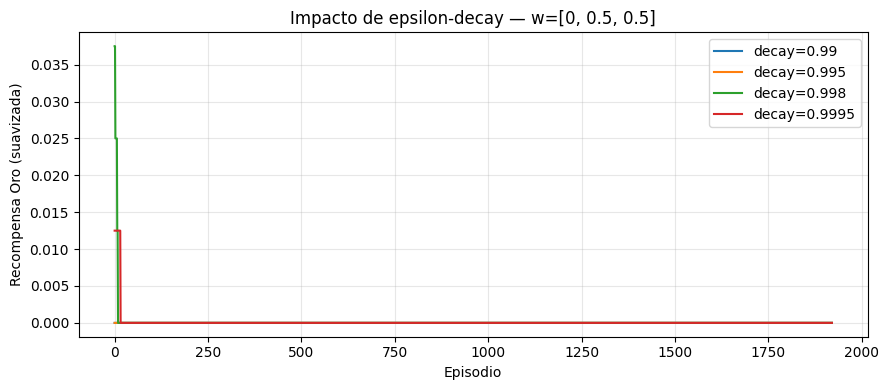

In [15]:
EPS_DECAYS = [0.990, 0.995, 0.998, 0.9995]

eps_results = {}
for ed in EPS_DECAYS:
    ag = ScalarizedQLearning(n_actions=4, weight=[0.0, 0.5, 0.5], gamma=GAMMA,
                             epsilon_decay=ed)
    hd, hg, hdm = ag.train(ENV_ID, n_episodes=2000)
    d, gold, diam = ag.evaluate(ENV_ID, n_eval=15)
    eps_results[ed] = {'gold': gold, 'diamond': diam, 'hist_gold': hg}
    print(f'  eps_decay={ed:.4f}: oro={gold:.3f}  diamante={diam:.3f}')

fig, ax = plt.subplots(figsize=(9, 4))
for ed, res in eps_results.items():
    smooth = np.convolve(res['hist_gold'], np.ones(80)/80, 'valid')
    ax.plot(smooth, label=f'decay={ed}', linewidth=1.5)
ax.set_xlabel('Episodio'); ax.set_ylabel('Recompensa Oro (suavizada)')
ax.set_title('Impacto de epsilon-decay — w=[0, 0.5, 0.5]')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('videos/rg_epsilon_analysis.png', dpi=100, bbox_inches='tight')
plt.show()

## 8. Enfoque 2: MPMOQLearning con GPI-LS

### Algoritmo MPMOQLearning

MPMOQLearning (Multi-Policy Multi-Objective Q-Learning) mantiene múltiples Q-tables $\{Q^{\pi_1}, Q^{\pi_2}, \ldots\}$, una por política aprendida. El **bucle externo** gestiona la selección de pesos mediante *Linear Support*; el **bucle interno** ejecuta Q-Learning estándar para el peso actual.

### GPI-LS (Generalized Policy Improvement + Linear Support)

La política **GPI** combina todos los Q-tables para decidir la acción óptima bajo cualquier vector de pesos $\mathbf{w}$:

$$\text{GPI}(s, \mathbf{w}) = \arg\max_a \max_{\pi \in \Pi} \mathbf{w}^\top \mathbf{Q}^\pi(s, a)$$

**Linear Support** identifica los vértices del casco convexo del frente de Pareto y concentra el entrenamiento en esos pesos, siendo más eficiente que el muestreo aleatorio.

### Ventajas sobre Escalarización
| Escalarización | MPMOQLearning + GPI-LS |
|---|---|
| Una política por entrenamiento | Múltiples políticas en una ejecución |
| Solo casco convexo | Puede descubrir más del frente |
| Simple | Requiere selección de pesos |
| Rápido | Más lento pero más completo |

In [16]:
GAMMA_GPI  = GAMMA
REF_POINT  = np.array([-1.1, -0.1, -0.1])
GPI_STEPS  = 100_000

print('Configurando MPMOQLearning con GPI-LS...')
print(f'  gamma      = {GAMMA_GPI}')
print(f'  ref_point  = {REF_POINT}')
print(f'  timesteps  = {GPI_STEPS:,}')

env_gpi      = mo_gym.make(ENV_ID)
env_gpi      = MORecordEpisodeStatistics(env_gpi, gamma=GAMMA_GPI)
eval_env_gpi = mo_gym.make(ENV_ID)

agent_gpi = MPMOQLearning(
    env_gpi,
    gamma               = GAMMA_GPI,
    initial_epsilon     = 1.0,
    final_epsilon       = 0.05,
    epsilon_decay_steps = GPI_STEPS,
    weight_selection_algo = 'gpi-ls',
    use_gpi_policy      = True,
    dyna                = True,
    gpi_pd              = True,
    log                 = False,
)

print('\nEntrenando MPMOQLearning (puede tardar ~1-2 minutos)...')
agent_gpi.train(
    total_timesteps             = GPI_STEPS,
    timesteps_per_iteration     = 10_000,
    eval_env                    = eval_env_gpi,
    num_eval_episodes_for_front = 10,
    ref_point                   = REF_POINT,
)
print('Entrenamiento completado.')
env_gpi.close(); eval_env_gpi.close()

Configurando MPMOQLearning con GPI-LS...
  gamma      = 0.95
  ref_point  = [-1.1 -0.1 -0.1]
  timesteps  = 100,000

Entrenando MPMOQLearning (puede tardar ~1-2 minutos)...


CCS: [] CCS size: 0
Next weight: [1. 0. 0.]


Adding value: [0. 0. 0.] to CCS.
W_corner: [array([1., 0., 0.]), array([0., 1., 0.]), array([0., 0., 1.])] W_corner size: 3
CCS: [array([0., 0., 0.], dtype=float32)] CCS size: 1
Next weight: [0. 1. 0.]


Adding value: [-0.0902  0.6285  0.    ] to CCS.
W_corner: [array([0.8745, 0.1255, 0.    ]), array([1., 0., 0.]), array([0., 1., 0.]), array([0., 0., 1.])] W_corner size: 4


CCS: [array([0., 0., 0.], dtype=float32), array([-0.0902,  0.6285,  0.    ])] CCS size: 2
Next weight: [1. 0. 0.]


...

Adding value: [-0.0902  0.6285  0.    ] to CCS.
removed value [-0.0902  0.6285  0.    ]
W_corner: [array([0.3983, 0.6017, 0.    ]), array([1., 0., 0.]), array([0., 1., 0.]), array([0., 0., 1.])] W_corner size: 4
CCS: [array([0.    , 0.5688, 0.    ]), array([-0.0902,  0.6285,  0.    ])] CCS size: 2
Next weight: [0.3983 0.6017 0.    ]


Adding value: [-0.0902  0.5672  0.    ] to CCS.
Value [-0.0902  0.5672  0.    ] is dominated. Discarding.
W_corner: [array([0.3983, 0.6017, 0.    ]), array([1., 0., 0.]), array([0., 1., 0.]), array([0., 0., 1.])] W_corner size: 4
CCS: [array([0.    , 0.5688, 0.    ]), array([-0.0902,  0.6285,  0.    ])] CCS size: 2
Next weight: [0.3983 0.6017 0.    ]


Adding value: [-0.262   0.4888  0.    ] to CCS.
Value [-0.262   0.4888  0.    ] is dominated. Discarding.
W_corner: [array([0.3983, 0.6017, 0.    ]), array([1., 0., 0.]), array([0., 1., 0.]), array([0., 0., 1.])] W_corner size: 4
CCS: [array([0.    , 0.5688, 0.    ]), array([-0.0902,  0.6285,  0.    ])] CCS size: 2
Next weight: [0. 1. 0.]


Adding value: [0.     0.6302 0.    ] to CCS.
removed value [-0.0902  0.6285  0.    ]
removed value [0.     0.5688 0.    ]
W_corner: [array([1., 0., 0.]), array([0., 0., 1.]), array([0., 1., 0.])] W_corner size: 3
CCS: [array([0.    , 0.6302, 0.    ])] CCS size: 1
Next weight: [0. 0. 1.]


Adding value: [0.     0.     0.6302] to CCS.
Entrenamiento completado.


In [17]:
def evaluate_gpi(agent, env_id, weight, n_episodes=10):
    """Evalua MPMOQLearning con un vector de pesos. Retorna (death, gold, diamond)."""
    env = mo_gym.make(env_id)
    episodes = []
    for _ in range(n_episodes):
        obs, _ = env.reset()
        ep_r = np.zeros(3)
        gamma_t = 1.0
        done = False
        while not done:
            action = int(agent_gpi.eval(np.array(obs, dtype=int), np.array(weight)))
            obs, r_vec, term, trunc, _ = env.step(action)
            ep_r    += gamma_t * r_vec
            gamma_t *= GAMMA_GPI
            done = term or trunc
        episodes.append(ep_r)
    env.close()
    return np.mean(episodes, axis=0).tolist()

# Evaluar con distintos pesos para aproximar el frente descubierto
GPI_EVAL_WEIGHTS = [
    ([0.0,  1.0,  0.0],  'Solo oro'),
    ([0.0,  0.0,  1.0],  'Solo diamante'),
    ([0.0,  0.5,  0.5],  'Balance'),
    ([-0.5, 0.5,  0.5],  'Evitar muerte'),
    ([0.0,  0.8,  0.2],  'Mas oro'),
    ([0.0,  0.2,  0.8],  'Mas diamante'),
]

print('Evaluando agente GPI-LS:')
print(f'  {"Peso":<30} {"muerte":>8} {"oro":>8} {"diamante":>10}')
print('  ' + '-'*60)
gpi_pts = []
for weight, lbl in GPI_EVAL_WEIGHTS:
    pt = evaluate_gpi(agent_gpi, ENV_ID, weight)
    gpi_pts.append(pt)
    print(f'  {lbl:<30} {pt[0]:>8.3f} {pt[1]:>8.3f} {pt[2]:>10.3f}')

gpi_pts = np.array(gpi_pts)

Evaluando agente GPI-LS:
  Peso                             muerte      oro   diamante
  ------------------------------------------------------------
  Solo oro                         -0.090    0.567      0.000
  Solo diamante                     0.000    0.000      0.630
  Balance                          -0.442    0.284      0.284
  Evitar muerte                    -0.180    0.455      0.455
  Mas oro                          -0.172    0.455      0.455
  Mas diamante                     -0.294    0.341      0.341


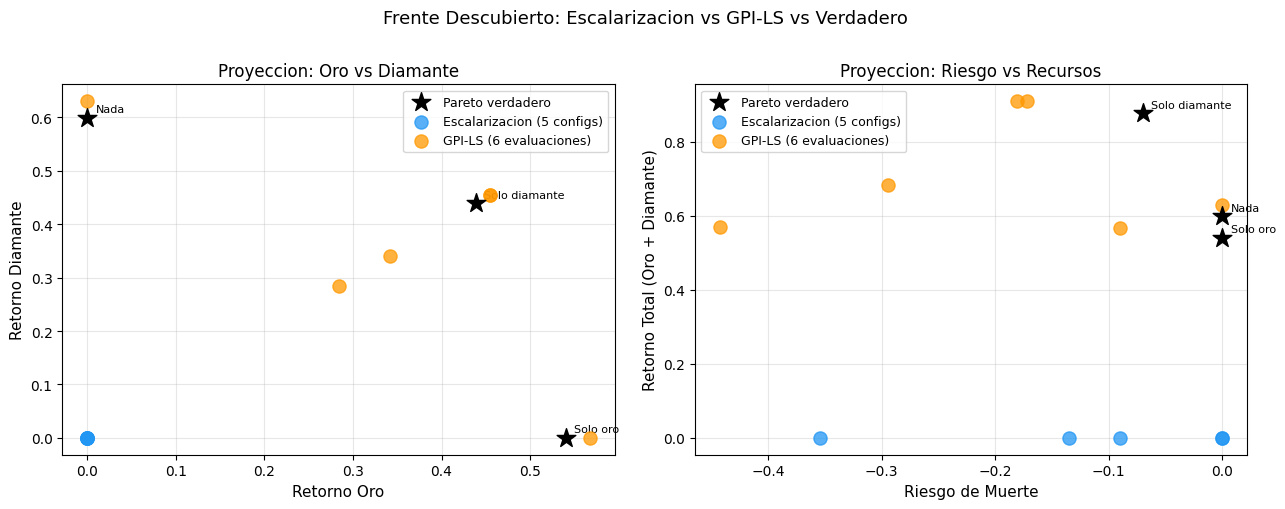

In [18]:
fig = plot_pareto_rg(
    TRUE_PARETO,
    discovered_list=[scalar_pts.tolist(), gpi_pts.tolist()],
    labels=[f'Escalarizacion ({len(scalar_pts)} configs)',
            f'GPI-LS ({len(gpi_pts)} evaluaciones)'],
    title='Frente Descubierto: Escalarizacion vs GPI-LS vs Verdadero'
)
plt.savefig('videos/rg_pareto_gpi.png', dpi=100, bbox_inches='tight')
plt.show()

In [19]:
print('Grabando videos del agente GPI-LS (3 estrategias)...')
VIDEO_WEIGHTS = [
    (np.array([0.0,  1.0, 0.0]),  'gold'),
    (np.array([0.0,  0.0, 1.0]),  'diamond'),
    (np.array([0.0,  0.5, 0.5]),  'both'),
]

for weight, label in VIDEO_WEIGHTS:
    print(f'\n  Estrategia: {label}  (w={weight})')
    policy_fn = (lambda w: lambda obs: int(agent_gpi.eval(np.array(obs, dtype=int), w)))(weight)
    frames = record_episode(ENV_ID, policy_fn, f'videos/rg_gpi_{label}', fps=4)
    if frames:
        gif_path = f'resources/agent_gifs/rg_gpi_{label}.gif'
        imageio.mimsave(gif_path, frames, fps=4, loop=0)
        print(f'  GIF guardado: {gif_path}')
        if label == 'both':
            _writer = imageio.get_writer('resources/agent_videos/rg_best.mp4', fps=4)
            for _f in frames: _writer.append_data(_f)
            _writer.close()
            print('  MP4 guardado: resources/agent_videos/rg_best.mp4')
        show_video(f'videos/rg_gpi_{label}')

Grabando videos del agente GPI-LS (3 estrategias)...

  Estrategia: gold  (w=[0. 1. 0.])


  Video guardado: videos/rg_gpi_gold.mp4  (10 pasos, 11 frames)
  GIF guardado: resources/agent_gifs/rg_gpi_gold.gif



  Estrategia: diamond  (w=[0. 0. 1.])


  Video guardado: videos/rg_gpi_diamond.mp4  (10 pasos, 11 frames)


  GIF guardado: resources/agent_gifs/rg_gpi_diamond.gif



  Estrategia: both  (w=[0.  0.5 0.5])


  Video guardado: videos/rg_gpi_both.mp4  (12 pasos, 13 frames)


  GIF guardado: resources/agent_gifs/rg_gpi_both.gif
  MP4 guardado: resources/agent_videos/rg_best.mp4


## 9. Análisis de Parámetros — GPI-LS

### Random vs GPI-LS (selección de pesos)

La estrategia `'random'` muestrea pesos uniformemente. `'gpi-ls'` concentra el esfuerzo en los vértices del casco convexo usando Linear Support, lo que suele ser más eficiente con el mismo número de pasos.

Comparando weight_selection_algo: random vs gpi-ls
Adding value: [0. 0. 0.] to CCS.


Adding value: [-0.4411  0.2053  0.2053] to CCS.
removed value [0. 0. 0.]


Adding value: [0.     0.6302 0.    ] to CCS.
removed value [-0.4411  0.2053  0.2053]


Adding value: [0.     0.     0.6302] to CCS.


Adding value: [0.     0.5688 0.5688] to CCS.
removed value [0.     0.     0.6302]


...

Adding value: [0.     0.     0.6302] to CCS.
removed value [0.     0.     0.6302]
W_corner: [array([1., 0., 0.]), array([0., 1., 0.]), array([0., 0., 1.])] W_corner size: 3
CCS: [array([0.    , 0.    , 0.6302])] CCS size: 1
Next weight: [0. 1. 0.]


Adding value: [-0.147   0.5042  0.    ] to CCS.
W_corner: [array([0.7743, 0.2257, 0.    ]), array([1., 0., 0.]), array([0., 0., 1.]), array([0., 1., 0.]), array([0.    , 0.5555, 0.4445])] W_corner size: 5
CCS: [array([0.    , 0.    , 0.6302]), array([-0.147 ,  0.5042,  0.    ])] CCS size: 2
Next weight: [0.     0.5555 0.4445]


Adding value: [0.     0.5133 0.5133] to CCS.
removed value [-0.147   0.5042  0.    ]
W_corner: [array([0.    , 0.1855, 0.8145]), array([0., 1., 0.]), array([0., 0., 1.]), array([1., 0., 0.])] W_corner size: 4
CCS: [array([0.    , 0.    , 0.6302]), array([0.    , 0.5133, 0.5133])] CCS size: 2
Next weight: [0. 1. 0.]


Adding value: [0.     0.6302 0.    ] to CCS.
W_corner: [array([0., 1., 0.]), array([0.    , 0.1855, 0.8145]), array([0.    , 0.8145, 0.1855]), array([0., 0., 1.]), array([1., 0., 0.])] W_corner size: 5
CCS: [array([0.    , 0.    , 0.6302]), array([0.    , 0.5133, 0.5133]), array([0.    , 0.6302, 0.    ])] CCS size: 3
Next weight: [0. 0. 1.]


Adding value: [0.     0.     0.6302] to CCS.
removed value [0.     0.     0.6302]
  gpi-ls: 4 evaluaciones completadas


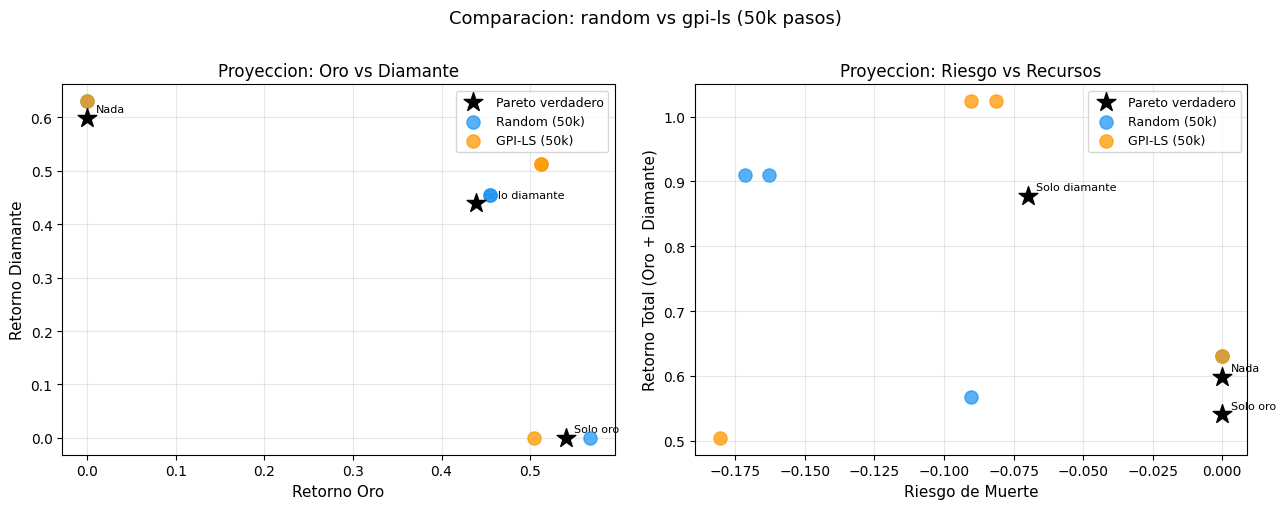

In [20]:
print('Comparando weight_selection_algo: random vs gpi-ls')

results_ws = {}
for ws_algo in ['random', 'gpi-ls']:
    env_cmp = mo_gym.make(ENV_ID)
    env_cmp = MORecordEpisodeStatistics(env_cmp, gamma=GAMMA)
    ev_cmp  = mo_gym.make(ENV_ID)
    try:
        ag_cmp = MPMOQLearning(
            env_cmp, gamma=GAMMA,
            initial_epsilon=1.0, final_epsilon=0.05, epsilon_decay_steps=50_000,
            weight_selection_algo=ws_algo, use_gpi_policy=True,
            dyna=True, gpi_pd=(ws_algo=='gpi-ls'), log=False,
        )
        ag_cmp.train(total_timesteps=50_000, timesteps_per_iteration=5_000,
                     eval_env=ev_cmp, num_eval_episodes_for_front=5,
                     ref_point=REF_POINT)
        pts = [evaluate_gpi(ag_cmp, ENV_ID, w) for w, _ in GPI_EVAL_WEIGHTS[:4]]
        results_ws[ws_algo] = pts
        print(f'  {ws_algo}: {len(pts)} evaluaciones completadas')
    except Exception as e:
        print(f'  {ws_algo}: error -> {e}')
    finally:
        env_cmp.close(); ev_cmp.close()

fig = plot_pareto_rg(
    TRUE_PARETO,
    discovered_list=[results_ws.get('random', []), results_ws.get('gpi-ls', [])],
    labels=['Random (50k)', 'GPI-LS (50k)'],
    title='Comparacion: random vs gpi-ls (50k pasos)'
)
plt.savefig('videos/rg_ws_comparison.png', dpi=100, bbox_inches='tight')
plt.show()

### Impacto de $\gamma$ en GPI-LS

Con transiciones **estocásticas** (muerte aleatoria en celdas enemigas), un $\gamma$ bajo penaliza más fuertemente los episodios que requieren muchos pasos, incentivando estrategias más cortas (solo un recurso en lugar de ambos).

CCS: [] CCS size: 0
Next weight: [1. 0. 0.]


Adding value: [0. 0. 0.] to CCS.
W_corner: [array([1., 0., 0.]), array([0., 1., 0.]), array([0., 0., 1.])] W_corner size: 3
CCS: [array([0., 0., 0.], dtype=float32)] CCS size: 1
Next weight: [0. 1. 0.]


Adding value: [-0.1044  0.2565  0.    ] to CCS.
W_corner: [array([0.7107, 0.2893, 0.    ]), array([1., 0., 0.]), array([0., 1., 0.]), array([0., 0., 1.])] W_corner size: 4
CCS: [array([0., 0., 0.], dtype=float32), array([-0.1044,  0.2565,  0.    ])] CCS size: 2
Next weight: [0. 0. 1.]


Adding value: [0.     0.     0.2316] to CCS.
removed value [0. 0. 0.]
W_corner: [array([0.7107, 0.2893, 0.    ]), array([1., 0., 0.]), array([0., 0., 1.]), array([0., 1., 0.]), array([0.    , 0.4745, 0.5255])] W_corner size: 5
CCS: [array([-0.1044,  0.2565,  0.    ]), array([0.    , 0.    , 0.2316])] CCS size: 2
Next weight: [0.7107 0.2893 0.    ]


Adding value: [0.     0.2316 0.    ] to CCS.
W_corner: [array([1., 0., 0.]), array([0.1926, 0.8074, 0.    ]), array([0.1065, 0.4467, 0.4467]), array([0.    , 0.4745, 0.5255]), array([0., 1., 0.]), array([0., 0., 1.])] W_corner size: 6
CCS: [array([-0.1044,  0.2565,  0.    ]), array([0.    , 0.    , 0.2316]), array([0.    , 0.2316, 0.    ])] CCS size: 3
Next weight: [0.1926 0.8074 0.    ]


...

Adding value: [0. 1. 0.] to CCS.
removed value [0. 1. 0.]
W_corner: [array([0. , 0.5, 0.5]), array([0., 1., 0.]), array([0., 0., 1.]), array([1., 0., 0.])] W_corner size: 4
CCS: [array([0., 0., 1.]), array([0., 1., 0.])] CCS size: 2
Next weight: [0. 0. 1.]


Adding value: [0. 0. 1.] to CCS.
removed value [0. 0. 1.]
W_corner: [array([0. , 0.5, 0.5]), array([0., 1., 0.]), array([0., 0., 1.]), array([1., 0., 0.])] W_corner size: 4
CCS: [array([0., 1., 0.]), array([0., 0., 1.])] CCS size: 2
Next weight: [0. 0. 1.]


Adding value: [0. 0. 1.] to CCS.
removed value [0. 0. 1.]
W_corner: [array([0. , 0.5, 0.5]), array([0., 1., 0.]), array([0., 0., 1.]), array([1., 0., 0.])] W_corner size: 4
CCS: [array([0., 1., 0.]), array([0., 0., 1.])] CCS size: 2
Next weight: [0.  0.5 0.5]


Adding value: [0. 1. 1.] to CCS.
removed value [0. 0. 1.]
removed value [0. 1. 0.]
W_corner: [array([1., 0., 0.]), array([0., 0., 1.]), array([0., 1., 0.])] W_corner size: 3
CCS: [array([0., 1., 1.])] CCS size: 1
Next weight: [0. 1. 0.]


Adding value: [0. 1. 1.] to CCS.
removed value [0. 1. 1.]
  gamma=1.0: completado (4 evaluaciones)


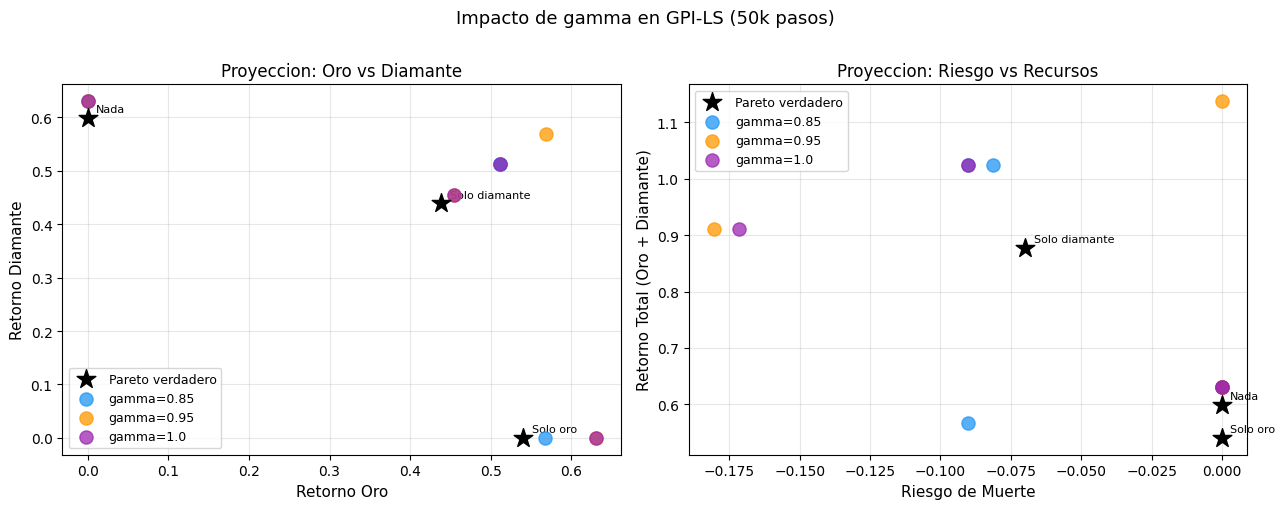

In [21]:
GAMMAS_GPI = [0.85, 0.95, 1.0]
gamma_gpi_results = {}

for g_val in GAMMAS_GPI:
    env_g = mo_gym.make(ENV_ID)
    env_g = MORecordEpisodeStatistics(env_g, gamma=g_val)
    ev_g  = mo_gym.make(ENV_ID)
    try:
        ag_g = MPMOQLearning(
            env_g, gamma=g_val,
            initial_epsilon=1.0, final_epsilon=0.05, epsilon_decay_steps=50_000,
            weight_selection_algo='gpi-ls', use_gpi_policy=True,
            dyna=True, gpi_pd=True, log=False,
        )
        ag_g.train(total_timesteps=50_000, timesteps_per_iteration=5_000,
                   eval_env=ev_g, num_eval_episodes_for_front=5, ref_point=REF_POINT)
        pts = [evaluate_gpi(ag_g, ENV_ID, w) for w, _ in GPI_EVAL_WEIGHTS[:4]]
        gamma_gpi_results[g_val] = pts
        print(f'  gamma={g_val}: completado ({len(pts)} evaluaciones)')
    except Exception as e:
        print(f'  gamma={g_val}: error -> {e}')
    finally:
        env_g.close(); ev_g.close()

fig = plot_pareto_rg(
    TRUE_PARETO,
    discovered_list=[gamma_gpi_results.get(g, []) for g in GAMMAS_GPI],
    labels=[f'gamma={g}' for g in GAMMAS_GPI],
    title='Impacto de gamma en GPI-LS (50k pasos)'
)
plt.savefig('videos/rg_gamma_gpi.png', dpi=100, bbox_inches='tight')
plt.show()

## 10. Comparación de Enfoques

| Característica | Q-Learning Escalarizado | MPMOQLearning + GPI-LS |
|---|---|---|
| Políticas por entrenamiento | 1 (por vector de pesos) | Múltiples (en una ejecución) |
| Cobertura del frente | Solo casco convexo | Mayor cobertura |
| Manejo de estocasticidad | Sí (Q-Learning estándar) | Sí |
| Requisitos | Ninguno especial | `pycddlib` para GPI-LS |
| Complejidad | Baja | Media |
| Uso de pesos a priori | Sí (requiere definir $\mathbf{w}$) | No (descubiertos automáticamente) |

In [22]:
def pareto_coverage(discovered, true_front=None, tol=0.12):
    """Porcentaje de puntos verdaderos cubiertos por el frente descubierto."""
    if true_front is None:
        true_front = TRUE_PARETO
    if not discovered:
        return 0.0
    covered = 0
    for pt in true_front:
        pt = np.array(pt)
        for d in discovered:
            if np.linalg.norm(np.array(d) - pt) < tol:
                covered += 1
                break
    return 100.0 * covered / len(true_front)

s_cov = pareto_coverage(scalar_pts.tolist())
g_cov = pareto_coverage(gpi_pts.tolist())

print('=' * 60)
print('     COMPARACION: ESCALARIZACION vs GPI-LS')
print('=' * 60)
print(f'  {"Metrica":<40} | {"Escalar":>8} | {"GPI-LS":>8}')
print('-' * 60)
print(f'  {"Configs/evaluaciones":<40} | {len(scalar_pts):>8} | {len(gpi_pts):>8}')
print(f'  {"Cobertura frente verdadero (%)":<40} | {s_cov:>7.0f}% | {g_cov:>7.0f}%')
print(f'  {"Max retorno oro alcanzado":<40} | {scalar_pts[:,1].max():>8.3f} | {gpi_pts[:,1].max():>8.3f}')
print(f'  {"Max retorno diamante alcanzado":<40} | {scalar_pts[:,2].max():>8.3f} | {gpi_pts[:,2].max():>8.3f}')
print(f'  {"Requiere pesos a priori":<40} | {"Si":>8} | {"No":>8}')
print(f'  {"Pasos de entrenamiento":<40} | {N_EPS * len(WEIGHT_CONFIGS):>8,} | {GPI_STEPS:>8,}')

     COMPARACION: ESCALARIZACION vs GPI-LS
  Metrica                                  |  Escalar |   GPI-LS
------------------------------------------------------------
  Configs/evaluaciones                     |        5 |        6
  Cobertura frente verdadero (%)           |       0% |     100%
  Max retorno oro alcanzado                |    0.000 |    0.567
  Max retorno diamante alcanzado           |    0.000 |    0.630
  Requiere pesos a priori                  |       Si |       No
  Pasos de entrenamiento                   |   10,000 |  100,000


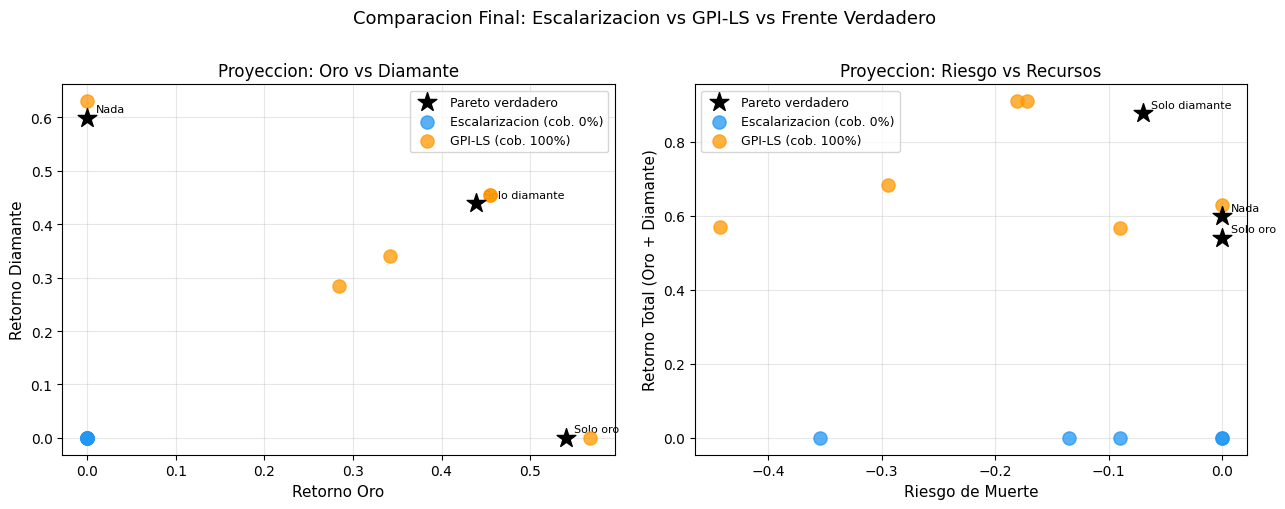

In [23]:
fig = plot_pareto_rg(
    TRUE_PARETO,
    discovered_list=[scalar_pts.tolist(), gpi_pts.tolist()],
    labels=[f'Escalarizacion (cob. {s_cov:.0f}%)',
            f'GPI-LS (cob. {g_cov:.0f}%)'],
    title='Comparacion Final: Escalarizacion vs GPI-LS vs Frente Verdadero'
)
plt.savefig('videos/rg_pareto_comparison.png', dpi=100, bbox_inches='tight')
plt.show()

## 11. Conclusiones

1. **El problema de los 3 objetivos** introduce un frente de Pareto en $\mathbb{R}^3$. Resource Gathering tiene solo 4 políticas no dominadas, pero ilustra perfectamente el conflicto entre **obtener recursos** y **evitar la muerte**.

2. **Escalarización lineal** es simple y efectiva para encontrar políticas específicas según preferencias del diseñador. Su limitación es que solo explora el casco convexo del frente; con 5 configuraciones de pesos cubre las 4 estrategias Pareto-óptimas en este caso particular.

3. **MPMOQLearning + GPI-LS** descubre múltiples políticas en una sola ejecución. La política GPI combina todos los Q-tables aprendidos, ofreciendo mayor flexibilidad. Requiere `pycddlib` y más configuración que la escalarización simple.

4. **El parámetro $\gamma$** tiene un impacto profundo en ambientes estocásticos: un agente miope ($\gamma$ bajo) prefiere estrategias de menos pasos para reducir la exposición a los enemigos.

5. **Comparación con Deep Sea Treasure**: DST tiene un frente de Pareto más rico (10 puntos vs 4) y es completamente determinista, lo que lo hace ideal para comparar PQL vs escalarización. Resource Gathering añade la complejidad de la estocasticidad, más cercana a problemas reales.